# Heart Disease Prediction — End-to-End Machine Learning Project

**Dataset:** UCI Heart Disease Dataset (Cleveland)  
**Goal:** Predict the presence of heart disease using KNN, Logistic Regression, and Neural Networks.


## 1. Import Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Load Dataset

In [53]:
# Load heart disease dataset from local csv
df = pd.read_csv('heart_disease.csv')

# Binarize the target variable (0 = no disease, >0 = disease)
# This is necessary because the models and metrics below expect binary classification.
target_col = df.columns[-1]
df[target_col] = (df[target_col] > 0).astype(int)

print("Dataset loaded from local CSV and target binarized.")
print(f"Shape: {df.shape}")


Dataset loaded from local CSV and target binarized.
Shape: (920, 16)


## 3. Basic Data Exploration

In [54]:
from IPython.display import display
print("=== First 5 rows ===")
display(df.head())


=== First 5 rows ===


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [55]:
print("=== Last 5 rows ===")
display(df.tail())


=== Last 5 rows ===


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [56]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Shape: (920, 16)
Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [57]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [58]:
print("=== Statistical Summary ===")
display(df.describe())


=== Statistical Summary ===


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


## 4. Data Quality Checks

In [59]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Missing values per column:")
print(df.isnull().sum())


Duplicate rows: 0

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [60]:
print("Unique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")


Unique values per column:
  id: 920 unique values
  age: 50 unique values
  sex: 2 unique values
  dataset: 4 unique values
  cp: 4 unique values
  trestbps: 61 unique values
  chol: 217 unique values
  fbs: 2 unique values
  restecg: 3 unique values
  thalch: 119 unique values
  exang: 2 unique values
  oldpeak: 53 unique values
  slope: 3 unique values
  ca: 4 unique values
  thal: 3 unique values
  num: 2 unique values


In [61]:
# Identify target column (last column or 'target'/'condition')
target_col = 'target' if 'target' in df.columns else df.columns[-1]
print(f"Target column: '{target_col}'")
print(f"\nClass distribution:")
print(df[target_col].value_counts())


Target column: 'num'

Class distribution:
num
1    509
0    411
Name: count, dtype: int64


## 5. Define Features (X) and Target (y)

In [62]:
target_col = 'target' if 'target' in df.columns else df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].copy()

# Encode target if categorical
if y.dtype == object:
    le = LabelEncoder()
    y = le.fit_transform(y)
    y = pd.Series(y)

# Encode any remaining categorical feature columns
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")


Features shape: (920, 15)
Target distribution:
num
1    509
0    411
Name: count, dtype: int64


## 6. Exploratory Data Analysis (EDA)

### 6.1 Target Class Distribution (Count Plot)

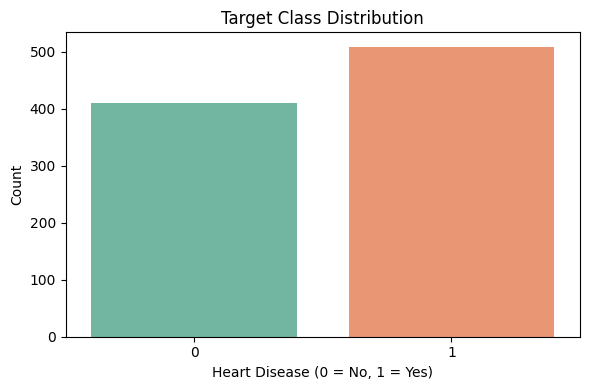

In [63]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 6.2 Correlation Heatmap

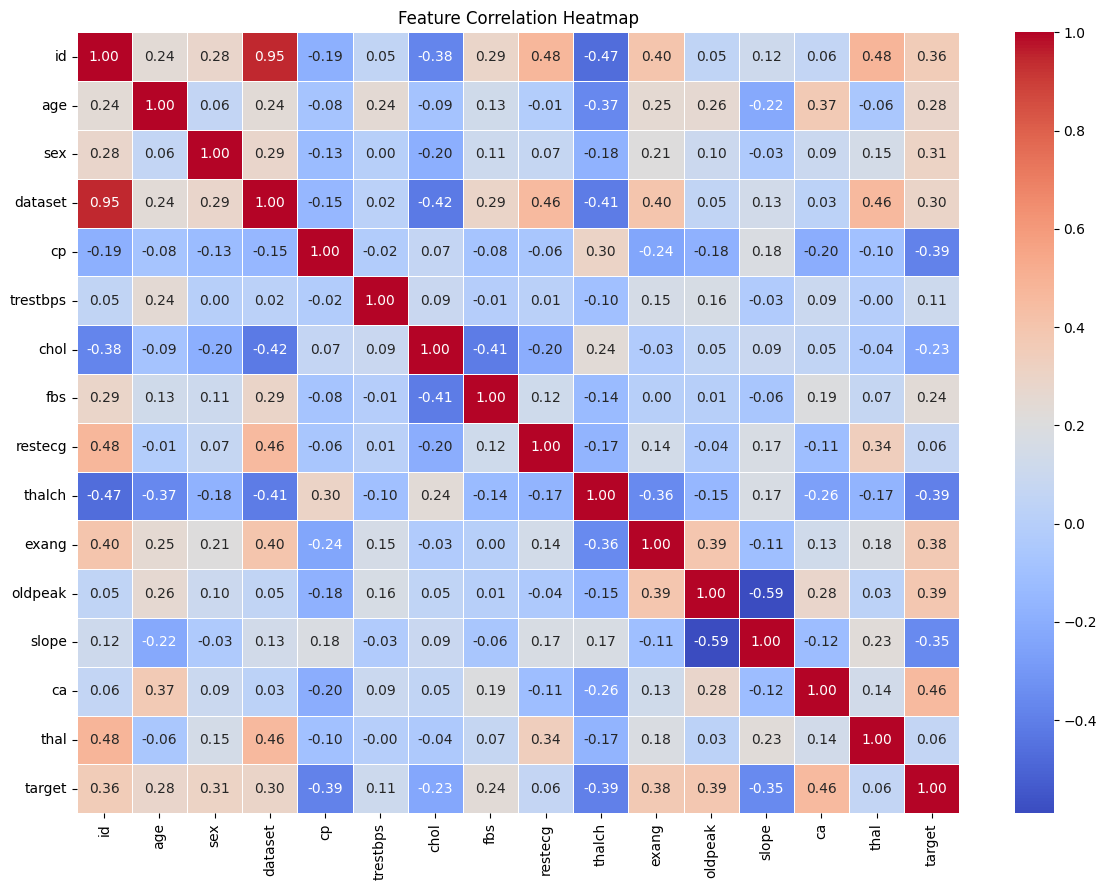

In [64]:
corr_df = X.copy()
corr_df['target'] = y.values
plt.figure(figsize=(12, 9))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


### 6.3 Feature Distributions (Histograms)

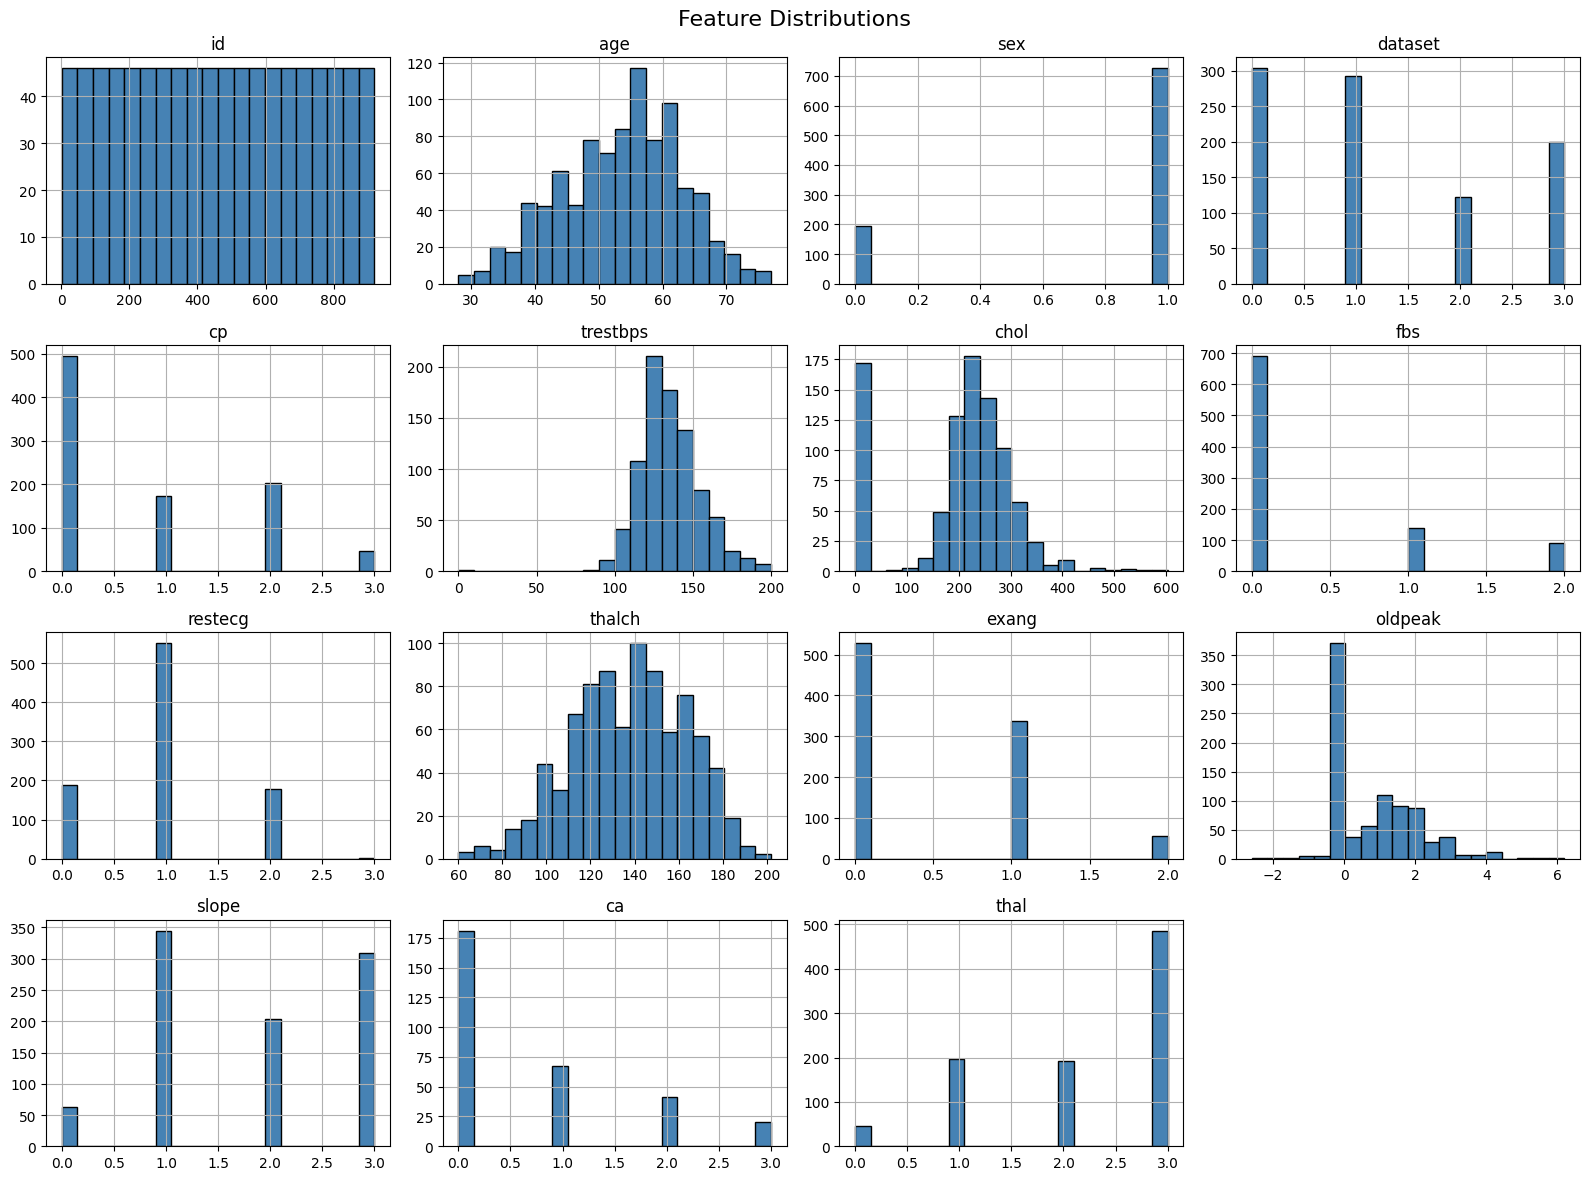

In [65]:
X.hist(figsize=(16, 12), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()


### 6.4 Age vs Target

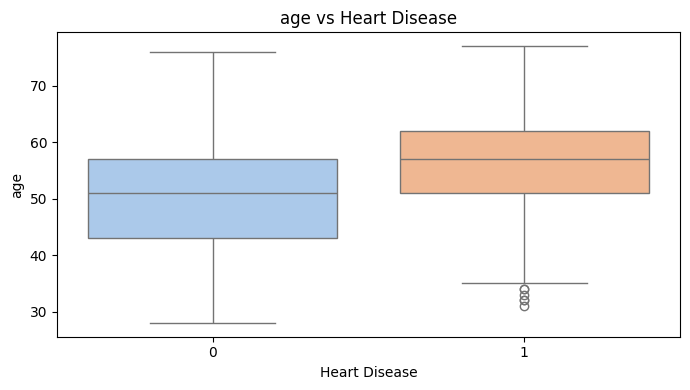

In [66]:
age_col = [c for c in X.columns if 'age' in c.lower()]
if age_col:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=y, y=X[age_col[0]], palette='pastel')
    plt.title(f'{age_col[0]} vs Heart Disease')
    plt.xlabel('Heart Disease')
    plt.tight_layout()
    plt.show()
else:
    print("No 'age' column found — skipping Age vs Target plot.")


### 6.5 Chest Pain Type vs Target

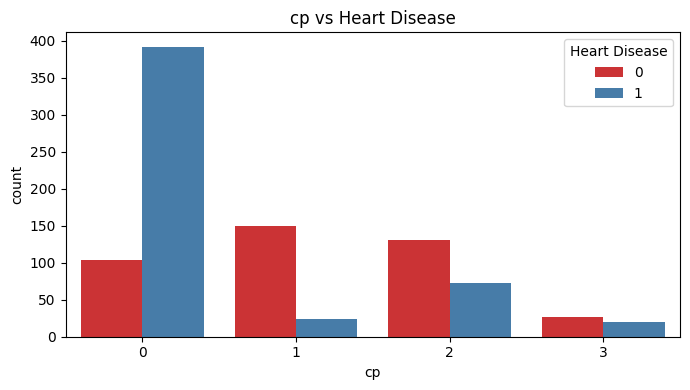

In [67]:
cp_col = [c for c in X.columns if 'cp' in c.lower() or 'chest' in c.lower() or 'pain' in c.lower()]
if cp_col:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=X[cp_col[0]], hue=y, palette='Set1')
    plt.title(f'{cp_col[0]} vs Heart Disease')
    plt.legend(title='Heart Disease')
    plt.tight_layout()
    plt.show()
else:
    # Fall back: first categorical-looking column
    cat_col = X.columns[0]
    plt.figure(figsize=(7, 4))
    sns.countplot(x=X[cat_col], hue=y, palette='Set1')
    plt.title(f'{cat_col} vs Heart Disease')
    plt.tight_layout()
    plt.show()


### 6.6 Sex vs Target

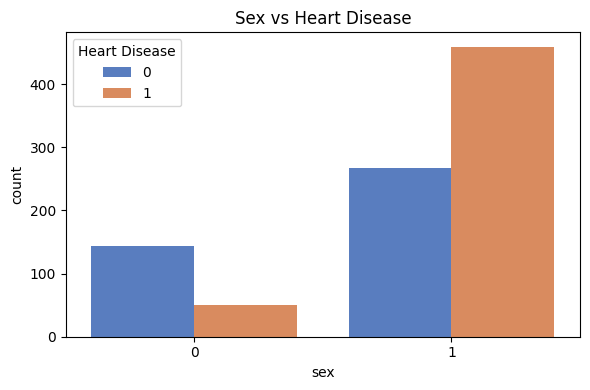

In [68]:
sex_col = [c for c in X.columns if 'sex' in c.lower() or 'gender' in c.lower()]
if sex_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=X[sex_col[0]], hue=y, palette='muted')
    plt.title('Sex vs Heart Disease')
    plt.legend(title='Heart Disease')
    plt.tight_layout()
    plt.show()
else:
    print("No sex/gender column found — skipping.")


### 6.7 Pairplot of Key Features

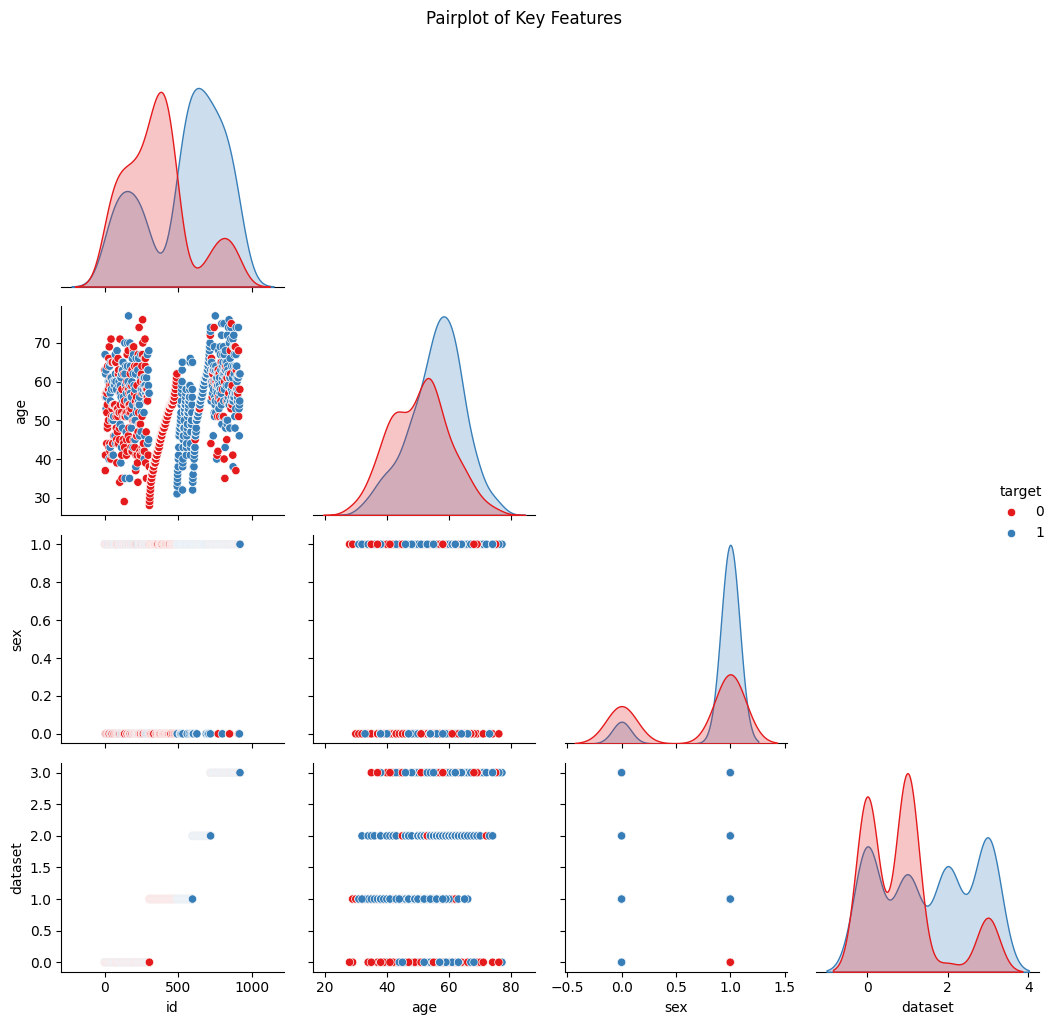

In [69]:
key_cols = list(X.columns[:4])   # first 4 features
pair_df = X[key_cols].copy()
pair_df['target'] = y.values
sns.pairplot(pair_df, hue='target', palette='Set1', corner=True)
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.tight_layout()
plt.show()


## 7. Data Preprocessing

In [70]:
# Drop duplicates
before = len(df)
X = X[~df.duplicated()].reset_index(drop=True)
y = y[~df.duplicated()].reset_index(drop=True)
print(f"Removed {before - len(X)} duplicate rows.")

# Handle missing values (mean imputation)
missing = X.isnull().sum().sum()
if missing > 0:
    X.fillna(X.mean(), inplace=True)
    print(f"Imputed {missing} missing values with column means.")
else:
    print("No missing values to impute.")


Removed 0 duplicate rows.
Imputed 817 missing values with column means.


## 8. Train-Test Split (80/20)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


Training samples : 736
Testing samples  : 184


## 9. Feature Scaling (StandardScaler)

In [72]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Features scaled with StandardScaler.")


Features scaled with StandardScaler.


## 10. K-Nearest Neighbours (KNN)

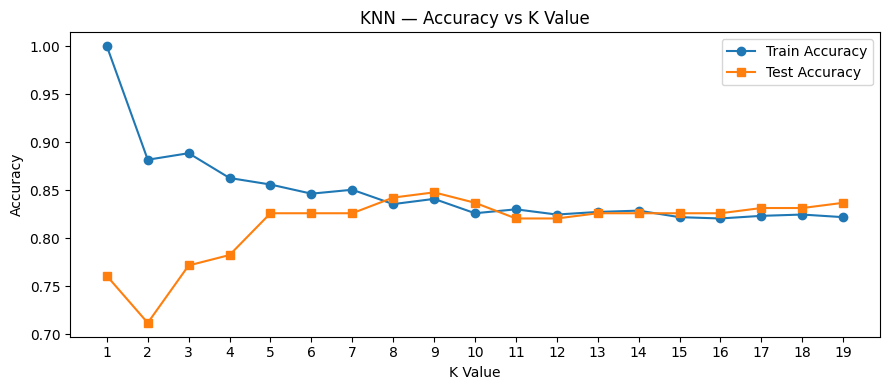

Best K = 9  |  Test Accuracy = 0.8478


In [73]:
# Evaluate KNN for K = 1 to 20
knn_train_accs = []
knn_test_accs  = []

for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    knn_train_accs.append(accuracy_score(y_train, knn.predict(X_train_sc)))
    knn_test_accs.append(accuracy_score(y_test, knn.predict(X_test_sc)))

plt.figure(figsize=(9, 4))
plt.plot(range(1, 20), knn_train_accs, marker='o', label='Train Accuracy')
plt.plot(range(1, 20), knn_test_accs,  marker='s', label='Test Accuracy')
plt.xticks(range(1, 20))
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K Value')
plt.legend()
plt.tight_layout()
plt.show()

best_k = np.argmax(knn_test_accs) + 1
print(f"Best K = {best_k}  |  Test Accuracy = {knn_test_accs[best_k-1]:.4f}")


                 === KNN Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        82
           1       0.88      0.84      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



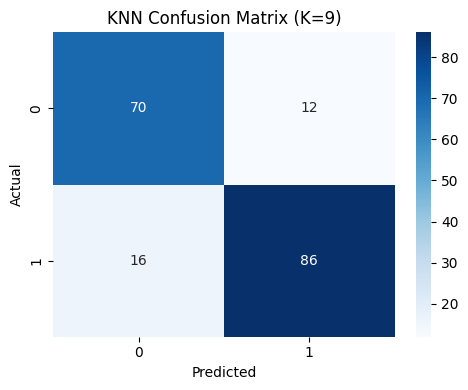

In [74]:
# Train final KNN with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
y_pred_knn  = knn_best.predict(X_test_sc)
y_prob_knn  = knn_best.predict_proba(X_test_sc)[:, 1]

print("                 === KNN Classification Report ===")
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 11. Logistic Regression

        === Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        82
           1       0.85      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



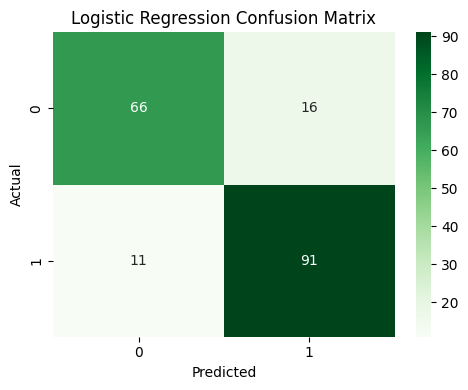

In [75]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("        === Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 12. Neural Network (MLPClassifier)

      === Neural Network Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        82
           1       0.86      0.86      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



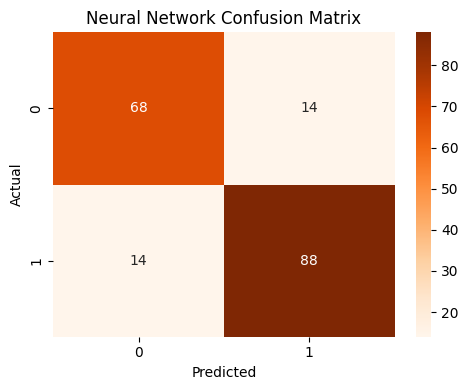

In [76]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train_sc, y_train)

y_pred_mlp = mlp.predict(X_test_sc)
y_prob_mlp = mlp.predict_proba(X_test_sc)[:, 1]

print("      === Neural Network Classification Report ===")
print(classification_report(y_test, y_pred_mlp))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Oranges')
plt.title('Neural Network Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 13. Model Comparison

In [77]:
def eval_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    eval_metrics(y_test, y_pred_knn, y_prob_knn, f'KNN (K={best_k})'),
    eval_metrics(y_test, y_pred_lr,  y_prob_lr,  'Logistic Regression'),
    eval_metrics(y_test, y_pred_mlp, y_prob_mlp, 'Neural Network (MLP)'),
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

display(results)


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.8533,0.8505,0.8922,0.8708,0.9181
1,KNN (K=9),0.8478,0.8776,0.8431,0.8600,0.8989
2,Neural Network (MLP),0.8478,0.8627,0.8627,0.8627,0.9055


### 13.1 ROC Curves

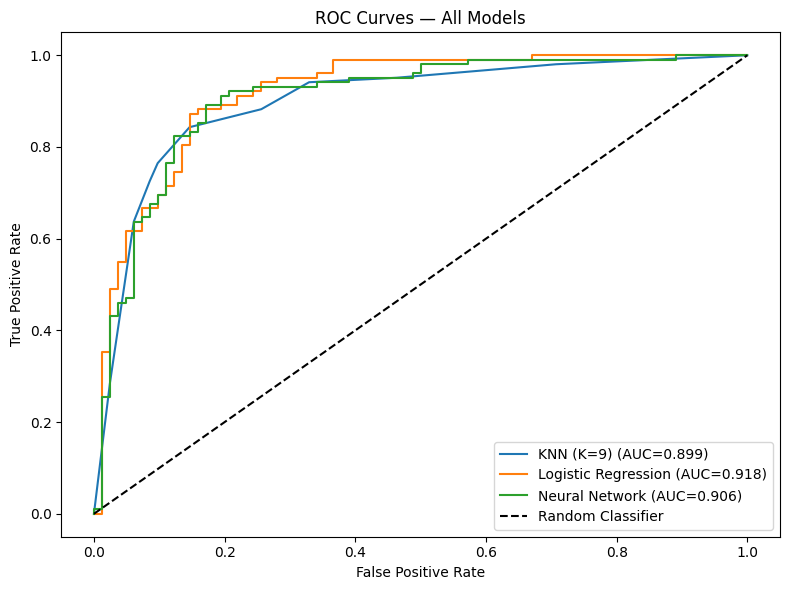

In [78]:
plt.figure(figsize=(8, 6))
for name, y_prob in [
    (f'KNN (K={best_k})', y_prob_knn),
    ('Logistic Regression', y_prob_lr),
    ('Neural Network',     y_prob_mlp),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()


### 13.2 Accuracy Comparison Bar Chart

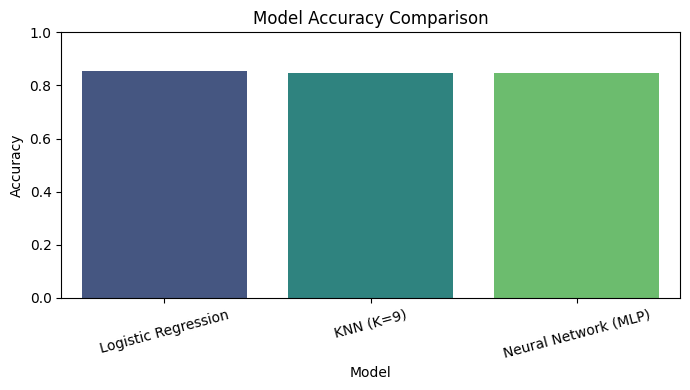

In [79]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results, x='Model', y='Accuracy', palette='viridis')
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 13.3 Precision / Recall / F1 Grouped Bar Chart

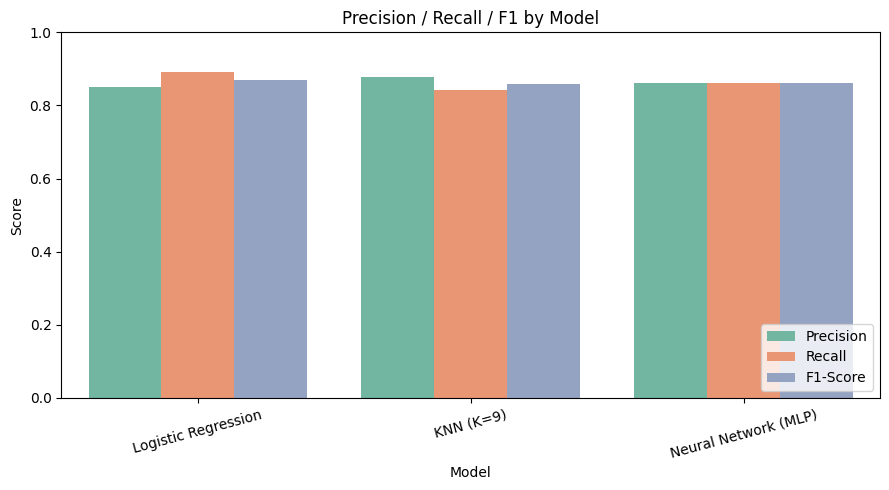

In [80]:
metrics_df = results.melt(
    id_vars='Model',
    value_vars=['Precision', 'Recall', 'F1-Score'],
    var_name='Metric', value_name='Score'
)
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.ylim(0, 1)
plt.title('Precision / Recall / F1 by Model')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 14. 5-Fold Cross-Validation

In [81]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all = scaler.fit_transform(X)   # scale full dataset for CV

cv_results = {}
for name, model in [
    (f'KNN (K={best_k})', KNeighborsClassifier(n_neighbors=best_k)),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Neural Network',      MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                                          solver='adam', max_iter=1000, random_state=42)),
]:
    scores = cross_val_score(model, X_all, y, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:30s}  Mean={scores.mean():.4f}  Std={scores.std():.4f}")


KNN (K=9)                       Mean=0.8087  Std=0.0210
Logistic Regression             Mean=0.8217  Std=0.0336
Neural Network                  Mean=0.8076  Std=0.0436


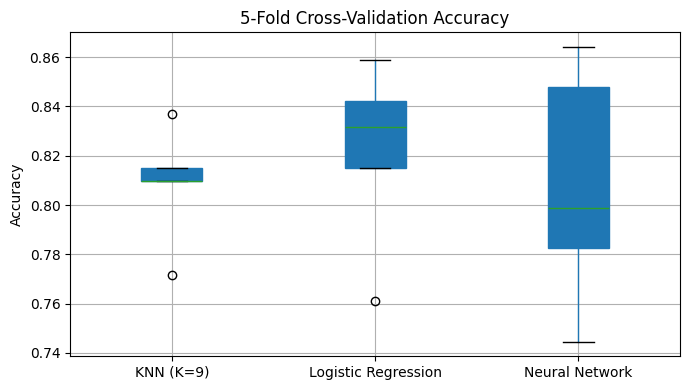

In [82]:
# Box plot of CV scores
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(7, 4))
cv_df.boxplot(patch_artist=True)
plt.title('5-Fold Cross-Validation Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


## 15. Unsupervised Learning — KMeans Clustering

### 15.1 Elbow Method

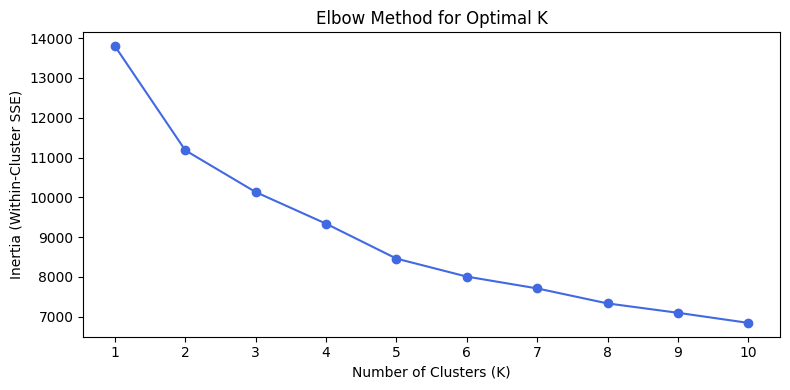

In [86]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_all)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='royalblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.tight_layout()
plt.show()


### 15.2 KMeans with K=2 + PCA Visualisation

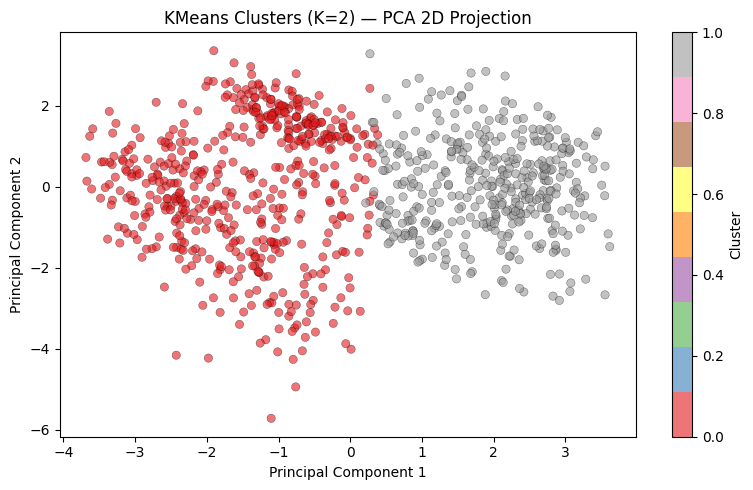

In [87]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_all)

# Reduce to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='Set1', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Cluster')
plt.title('KMeans Clusters (K=2) — PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()


In [88]:
# Compare KMeans clusters vs actual labels
print("Cluster vs Actual Target cross-tabulation:")
ct = pd.crosstab(cluster_labels, y, rownames=['Cluster'], colnames=['Actual Target'])
display(ct)


Cluster vs Actual Target cross-tabulation:


Actual Target,0,1
Cluster,,
0,342,182
1,69,327


## 16. Final Results Summary

In [89]:
print("=" * 60)
print("          FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
display(results)

best_acc_model = results.iloc[0]['Model']
best_auc_model = results.loc[results['AUC-ROC'].idxmax(), 'Model']

print(f"\n🏆 Best Model by Accuracy : {best_acc_model}  ({results.iloc[0]['Accuracy']:.4f})")
print(f"🏆 Best Model by AUC-ROC  : {best_auc_model}  ({results['AUC-ROC'].max():.4f})")
print("=" * 60)


          FINAL MODEL PERFORMANCE SUMMARY


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.8533,0.8505,0.8922,0.8708,0.9181
1,KNN (K=9),0.8478,0.8776,0.8431,0.8600,0.8989
2,Neural Network (MLP),0.8478,0.8627,0.8627,0.8627,0.9055



🏆 Best Model by Accuracy : Logistic Regression  (0.8533)
🏆 Best Model by AUC-ROC  : Logistic Regression  (0.9181)
